<a href="https://colab.research.google.com/github/HansajaLiyanagama/Git-session-1/blob/main/E_23_202_Lab_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

# This will open a file picker dialog
uploaded = files.upload()

Saving horse.jpeg to horse.jpeg


In [7]:
!pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

[[[19 40 91]
  [22 43 94]
  [20 41 96]
  [15 38 94]
  [16 40 98]]

 [[18 39 90]
  [21 42 93]
  [19 41 93]
  [15 39 93]
  [14 39 95]]

 [[17 38 89]
  [20 41 92]
  [20 41 93]
  [16 37 92]
  [16 39 95]]

 [[17 38 89]
  [20 41 92]
  [19 40 92]
  [16 38 90]
  [18 41 97]]

 [[16 37 88]
  [13 34 85]
  [10 31 83]
  [ 8 30 82]
  [17 40 96]]]


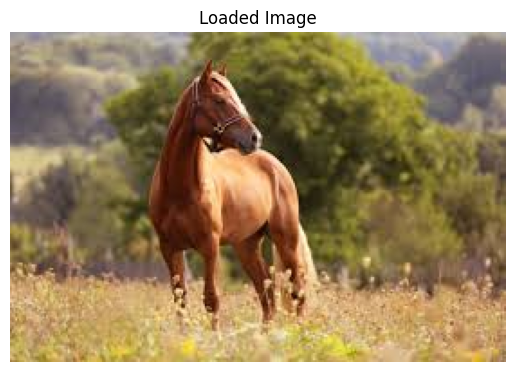

In [6]:
import cv2
import matplotlib.pyplot as plt

# Task 1
img = cv2.imread("horse.jpeg")

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image 'horse.jpeg'. Please ensure the file was uploaded correctly and is not corrupted.")
else:
    print(img[100:105, 100:105])
    # OpenCV loads images as BGR, matplotlib expects RGB, so we convert
    plt.imshow(img[:,:,::-1])
    plt.title("Loaded Image")
    plt.axis('off')
    plt.show()

An image is represented as a 3D array where each pixel contains three numerical values corresponding to the Blue, Green, and Red (BGR) channels. These values typically range from 0 to 255, where higher values indicate stronger intensity of that color. When observing a small 5×5 patch, we can see how neighboring pixel values change gradually, which results in smooth transitions such as shading and edges in the image.
Computers process images at this numerical level because they cannot interpret visual content directly like humans. Instead, all image processing operations—such as filtering, edge detection, and recognition—are performed using mathematical operations on these pixel values.
Even if two images have similar numeric ranges, their spatial arrangement of values differs. This arrangement is what forms patterns, shapes, and structures, making the images visually distinct.


[[53 56 55 52 55]
 [52 55 54 52 53]
 [51 54 54 51 53]
 [51 54 53 51 55]
 [50 47 44 43 54]]


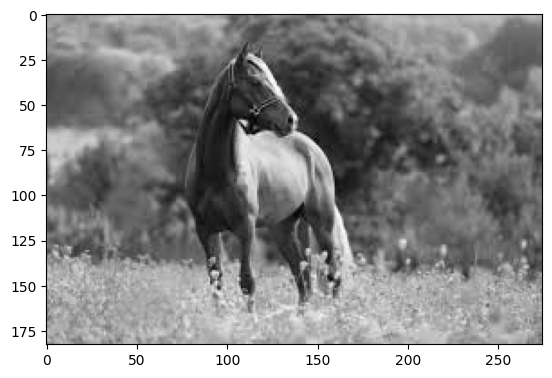

In [11]:
# Task 2
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gray[100:105, 100:105])
plt.imshow(gray, cmap='gray')


Grayscale conversion reduces the image from three color channels to a single intensity channel. This removes color information but preserves structural details such as edges, shapes, and textures.
The lost information includes color variations, which can be important for distinguishing objects in some cases. However, the preserved information—intensity differences—is often sufficient for many tasks like edge detection and feature extraction.
Grayscale is widely used because it simplifies computation (less data) while still retaining essential structural information. However, modern vision systems often use color because it provides additional discriminative features that improve accuracy in complex tasks.


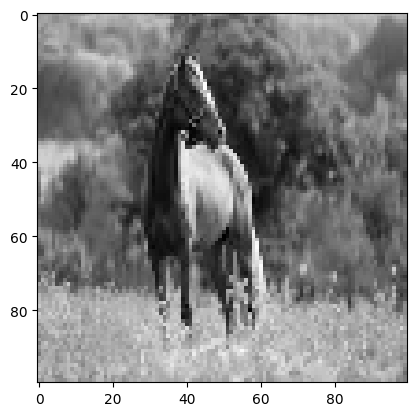

In [12]:
# Task 3
# Resize and Zoom
small = cv2.resize(gray, (100,100))
plt.imshow(small, cmap='gray')

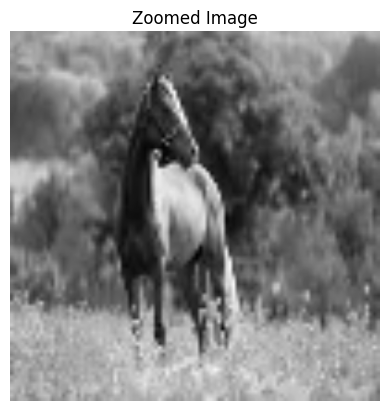

In [13]:
big = cv2.resize(small, (500, 500))
plt.imshow(big, cmap='gray')
plt.title("Zoomed Image")
plt.axis('off')
plt.show()

When the image is resized to a smaller resolution, fine details such as edges and textures are lost due to fewer pixels representing the image. When it is resized back to a larger size, the missing details cannot be recovered, leading to blur and pixelation.
Pixelation occurs because each enlarged pixel becomes visible, while blur results from interpolation methods trying to smooth missing information.
Reducing resolution can negatively impact tasks like object detection and recognition because important features may disappear. However, in some cases, it can help reduce noise and simplify the image, making large-scale structures more prominent and easier to process.


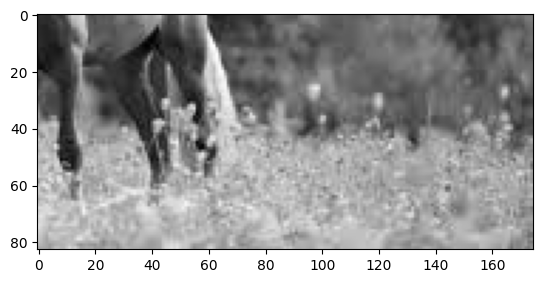

In [21]:
# Task 4: Crop central region
crop = gray[100:400, 100:400]
plt.imshow(crop, cmap='gray')

Cropping isolates specific regions of interest (ROI) in an image, allowing algorithms to focus only on relevant parts. A central crop may contain important objects, while an edge crop might contain background or less useful information.
Spatial context is important because objects are often understood in relation to their surroundings. For example, a face crop may help in facial recognition, but removing too much context may make it harder to interpret expressions or scene information.
Cropping does not always improve recognition. If important contextual information is removed, it can reduce accuracy instead of improving it.


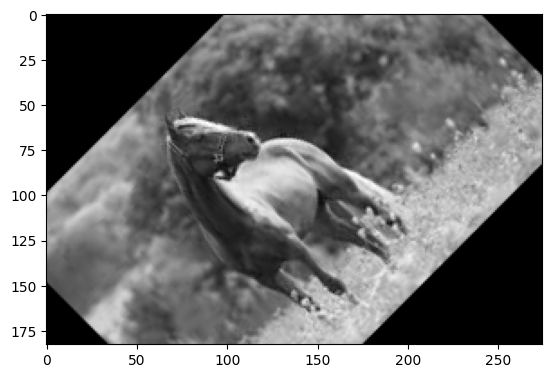

In [18]:
# Task 5
# Flip and rotate to explore viewpoint changes
flip_h = cv2.flip(gray, 1)
cx = gray.shape[1] // 2
cy = gray.shape[0] // 2
M = cv2.getRotationMatrix2D(center=(cx,cy), angle=45, scale=1.0)
w = gray.shape[1]
h = gray.shape[0]
rot = cv2.warpAffine(gray, M, (w, h))
plt.imshow(flip_h, cmap='gray')
plt.imshow(rot, cmap='gray')

Horizontal flipping often preserves the meaning of the image (e.g., landscapes or objects), while vertical flipping can sometimes distort interpretation (e.g., upside-down scenes). Rotation can also affect interpretation depending on the angle.
These transformations simulate viewpoint variations caused by camera movement or orientation changes. In machine learning, such transformations are used in data augmentation to improve model robustness.
Whether flipped objects should be treated the same depends on the task. For example, a flipped face is still a face, but flipping text or certain symbols may change their meaning entirely.


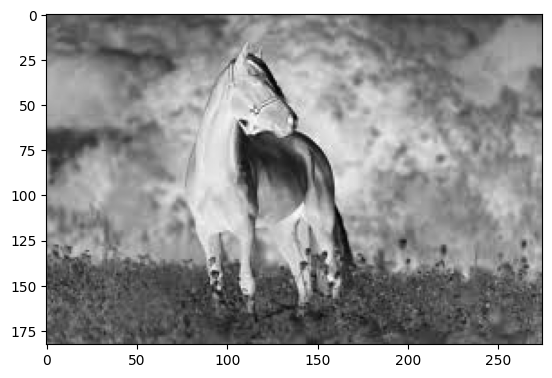

In [15]:
# Task 6: Invert Pixel Intensities (Negative Image)
inv = cv2.bitwise_not(gray)
plt.imshow(inv, cmap='gray')

When the image intensities are inverted, bright areas become dark and dark areas become bright. This changes the visual appearance and can make the image harder for humans to interpret because it is opposite to natural viewing conditions.
Negative imaging can still be useful in applications such as medical imaging and forensic analysis because inversion may highlight hidden details, improve contrast, and reveal structures that are difficult to notice in the original image.

More to think:

Yes. Inversion can reveal patterns that the human eye may miss in the original image by increasing contrast between certain regions and making faint details more visible.


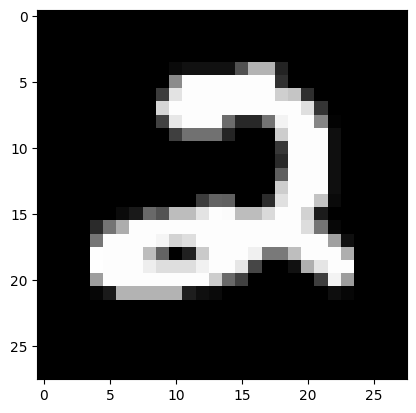

In [16]:
# Task 7: Convert Digit CSV to Images
data = pd.read_csv("Digits_Lab_01.csv").to_numpy()
digit = data[0].reshape(28,28)
plt.imshow(digit, cmap='gray')

The digit CSV file stores image pixels as rows of numbers. By reshaping each row into a 28×28 matrix, the numeric values form a meaningful visual pattern that represents a handwritten digit. This shows that images are simply organized collections of pixel intensity values.
Correct reshaping is important in machine learning because the spatial arrangement of pixels determines the structure and appearance of the digit. Incorrect reshaping would distort the image and reduce recognition accuracy.

More to Think:

If shuffled row order still produces recognizable digits after reshaping, it means the spatial encoding of pixels is preserved consistently within the dataset. The position of each pixel value in the sequence is important for reconstructing the correct image structure.


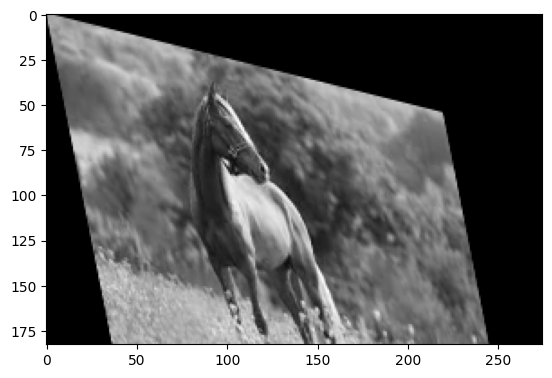

In [20]:
# Task 8: Apply a Simple Affine Transform
pts1 = np.float32([[0,0],[100,0],[0,100]])
pts2 = np.float32([[0,0],[80,20],[20,100]])
M = cv2.getAffineTransform(pts1, pts2)
w = gray.shape[1]
h = gray.shape[0]
aff = cv2.warpAffine(gray, M, (w,h))
plt.imshow(aff, cmap='gray')

Affine transformations such as shear or shift change the shape and position of objects in the image. Shearing can stretch or tilt objects, while shifting moves them to a different location. These transformations simulate viewpoint and perspective changes that occur in real camera movements.
Such distortions can affect how objects are recognized because their original appearance changes. Affine transformations are important in image processing and computer vision for understanding how models handle different viewing conditions.

More to think:

A classifier trained only on undistorted images may struggle to recognize sheared versions because the object shapes appear different. Training with transformed images can improve the model’s ability to handle viewpoint variations.


Final Reflection


Viewing images as numeric matrices changed my understanding of images from just an image to structured collections of pixel values processed mathematically by computers. Simple operations such as resizing, cropping, inversion, and transformation showed how changing pixel values directly affects image appearance and interpretation. The transformation that taught me the most was resizing because it clearly demonstrated how resolution affects detail, sharpness, and image quality.


After running the cell above, a file picker dialog will appear, allowing you to select and upload files from your local machine to the Colab environment. The `uploaded` variable will then contain a dictionary of the uploaded files.